# TRENDY Model NBP Analysis

Plots of area-weighted global mean Net Biome Productivity (NBP) from TRENDY v2025 model runs.

- **Data source**: Pre-processed annual global means in `global_means/` (CSV files)
- **Experiments**: S0 (pre-industrial CO₂ + climate), S1 (+CO₂), S2 (+CO₂ + climate), S3 (+CO₂ + climate + land use)
- **Units**: PgC yr⁻¹ (positive = land carbon sink), converted from area-weighted mean kg C m⁻² s⁻¹ × Earth land area (~1.496×10¹⁴ m²)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

# Load all CSV files from global_means/
csv_files = sorted(glob.glob('global_means/*_annual_global_mean.csv'))
print(f"Found {len(csv_files)} CSV files")

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# Convert NBP from area-weighted global mean (kg C m-2 s-1) to global total (PgC/yr)
# global_total = global_mean × Earth_land_area × seconds_per_year / 1e12
# Earth land area ≈ 1.496e14 m², seconds/year ≈ 3.156e7
SECONDS_PER_YEAR = 365.25 * 24 * 3600
EARTH_LAND_AREA = 1.496e14  # m²
KG_TO_PG = 1e-12
df['nbp_PgC_yr'] = df['nbp_global_mean'] * EARTH_LAND_AREA * SECONDS_PER_YEAR * KG_TO_PG

models = sorted(df['model'].unique())
experiments = ['S0', 'S1', 'S2', 'S3']
print(f"Models ({len(models)}): {', '.join(models)}")
print(f"Experiments: {experiments}")
print(f"Year range: {df.year.min()} - {df.year.max()}")
df.head()

Found 78 CSV files
Models (20): CABLE-POP, CARDAMOM, CLASSIC, CLM-FATES, CLM6.0, DLEM, E3SM, EDv3, ELM-FATES, GDSTEM, IBIS, ISAM, JSBACH, JULES, LPJ-EOSIM, LPJ-GUESS, LPJmL, LPX-Bern, ORCHIDEE, VISIT-UT
Experiments: ['S0', 'S1', 'S2', 'S3']
Year range: 1699 - 2025


,model,experiment,year,nbp_global_mean,nbp_PgC_yr
0,CABLE-POP,S0,1700,1.965505e-10,0.927918
1,CABLE-POP,S0,1701,-2.241571e-10,-1.058249
2,CABLE-POP,S0,1702,1.687766e-10,0.796797
3,CABLE-POP,S0,1703,2.321915e-10,1.096180
4,CABLE-POP,S0,1704,-3.019592e-10,-1.425554


## NBP by Experiment — All Models

Each panel shows one experiment with all individual model time series and the multi-model mean.

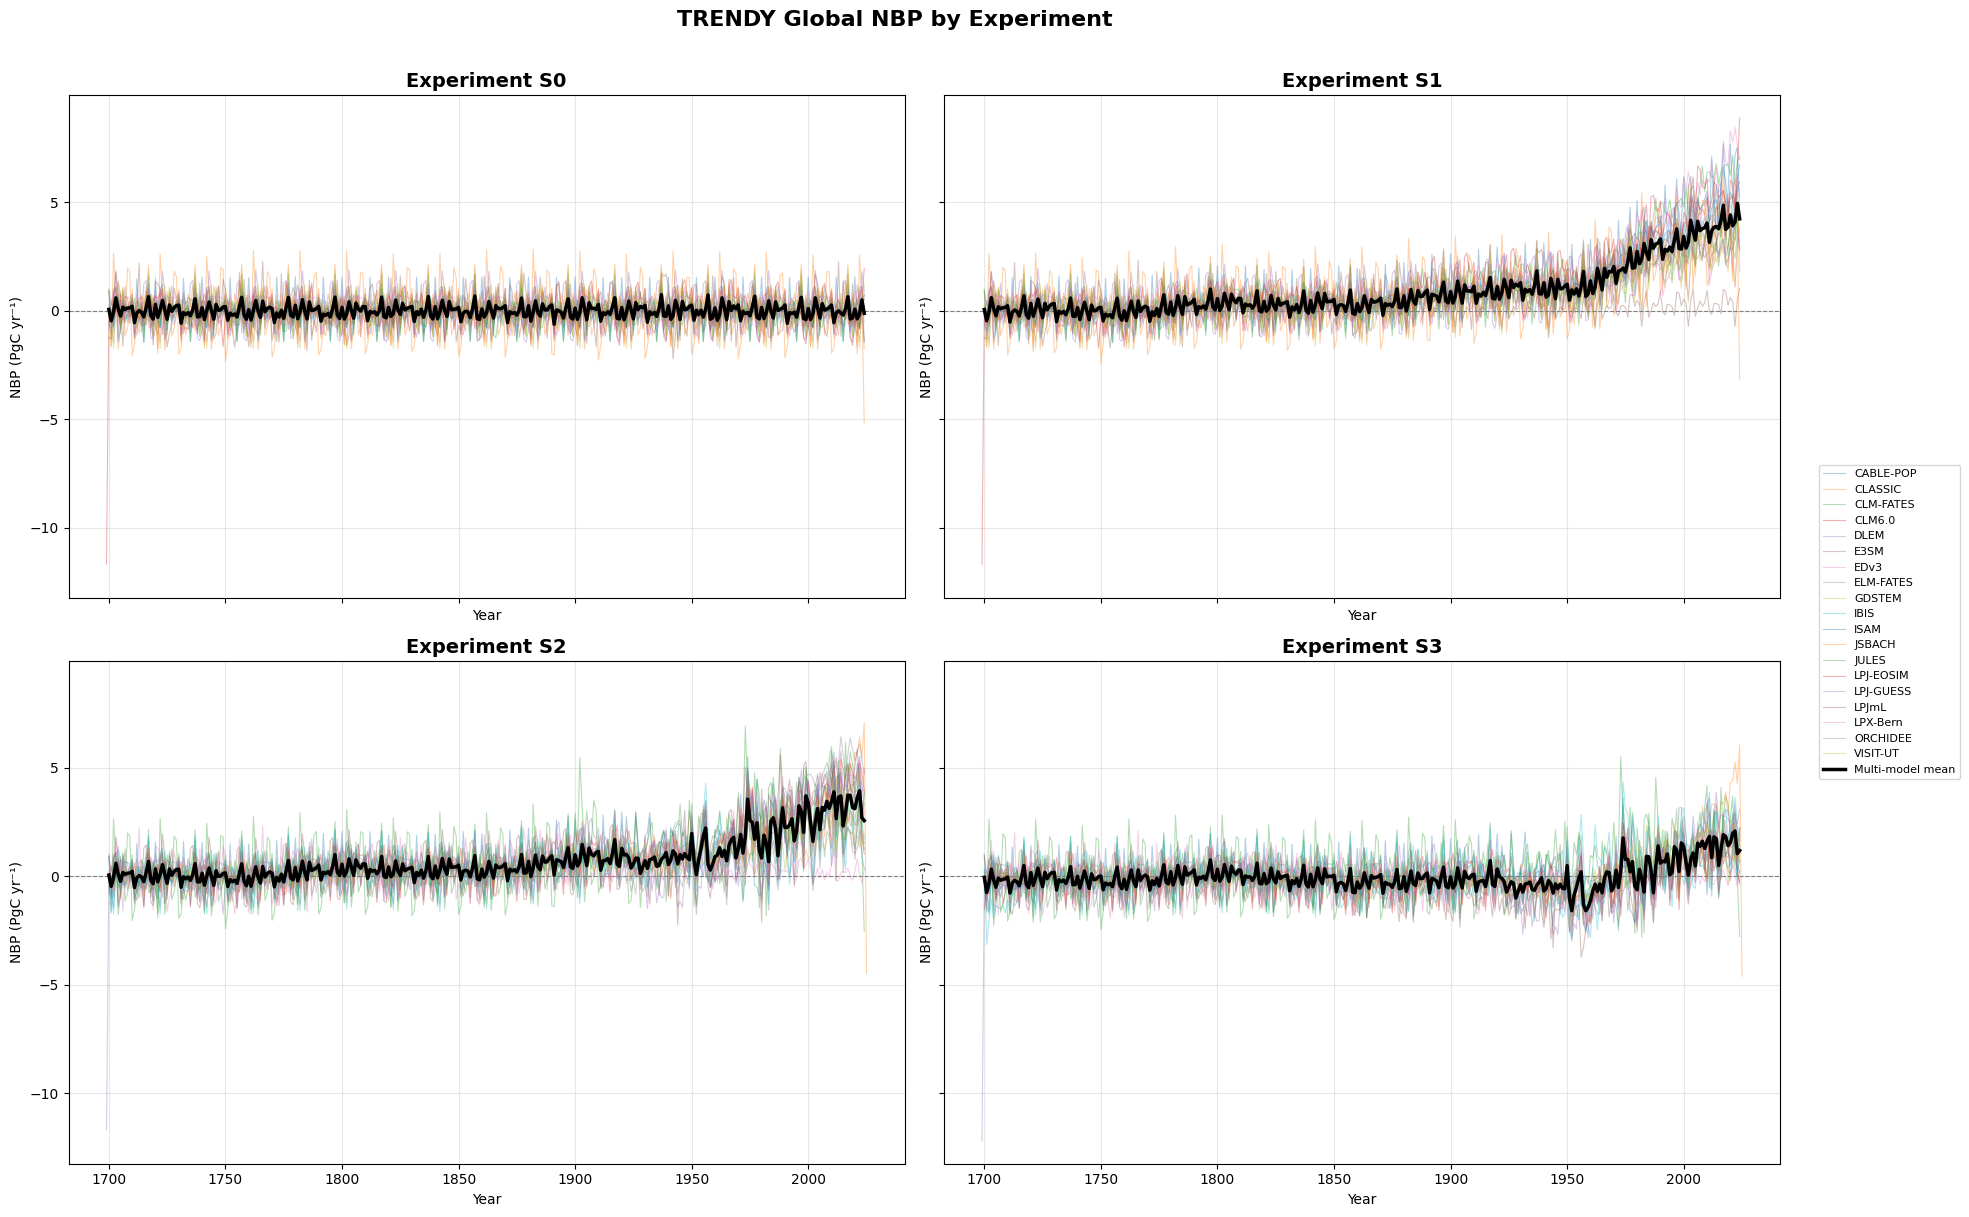

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey=True)
exp_colors = {'S0': '#1b9e77', 'S1': '#d95f02', 'S2': '#7570b3', 'S3': '#e7298a'}

for ax, exp in zip(axes.flat, experiments):
    sub = df[df['experiment'] == exp]
    
    # Plot individual models
    for model in models:
        msub = sub[sub['model'] == model]
        if len(msub) > 0:
            ax.plot(msub['year'], msub['nbp_PgC_yr'], alpha=0.35, linewidth=0.8, label=model)
    
    # Multi-model mean (only where ≥3 models overlap)
    pivot = sub.pivot_table(index='year', columns='model', values='nbp_PgC_yr')
    mask = pivot.count(axis=1) >= 3
    mmm = pivot.loc[mask].mean(axis=1)
    ax.plot(mmm.index, mmm.values, color='black', linewidth=2.5, label='Multi-model mean', zorder=10)
    
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_title(f'Experiment {exp}', fontsize=14, fontweight='bold')
    ax.set_ylabel('NBP (PgC yr⁻¹)')
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)

# Single legend for all panels
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), 
           fontsize=8, ncol=1, frameon=True)
fig.suptitle('TRENDY Global NBP by Experiment', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## NBP by Model — Comparing Experiments

Each panel shows one model with S0–S3 overlaid.

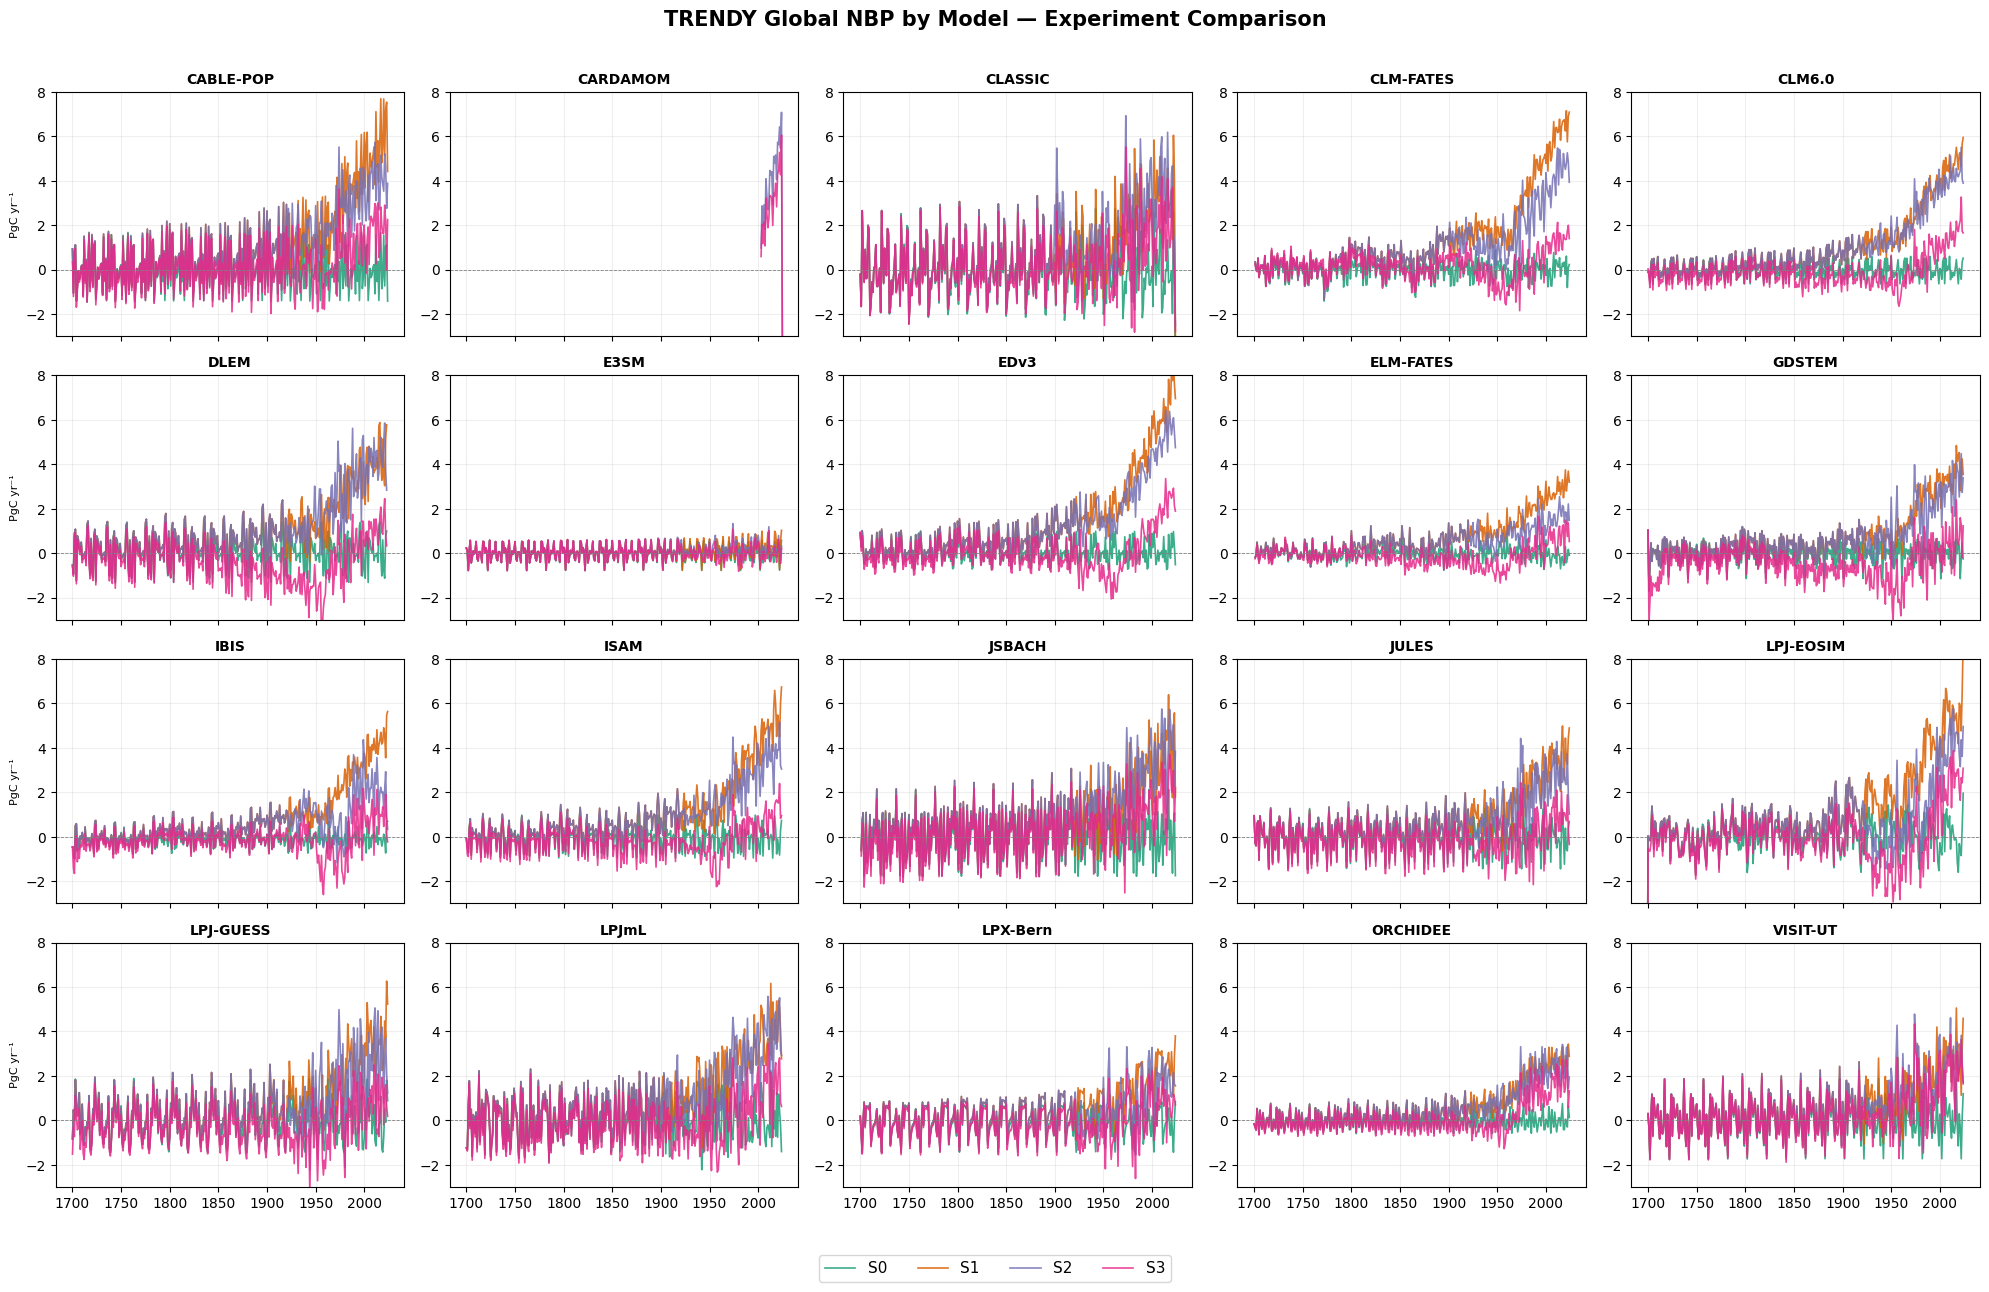

In [7]:
ncols = 5
nrows = int(np.ceil(len(models) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.2), sharex=True)

for idx, model in enumerate(models):
    ax = axes.flat[idx]
    msub = df[df['model'] == model]
    
    for exp in experiments:
        esub = msub[msub['experiment'] == exp]
        if len(esub) > 0:
            ax.plot(esub['year'], esub['nbp_PgC_yr'], 
                    color=exp_colors[exp], linewidth=1.2, label=exp, alpha=0.85)
    
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.set_title(model, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.2)
    ax.set_ylim(-3,8)
    if idx % ncols == 0:
        ax.set_ylabel('PgC yr⁻¹', fontsize=8)

# Hide unused axes
for idx in range(len(models), len(axes.flat)):
    axes.flat[idx].set_visible(False)

# Shared legend
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=11,
           bbox_to_anchor=(0.5, -0.02), frameon=True)
fig.suptitle('TRENDY Global NBP by Model — Experiment Comparison', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## Multi-Model Mean ± 1σ — Experiment Comparison

Ensemble mean with ±1 standard deviation shading across all models for each experiment.

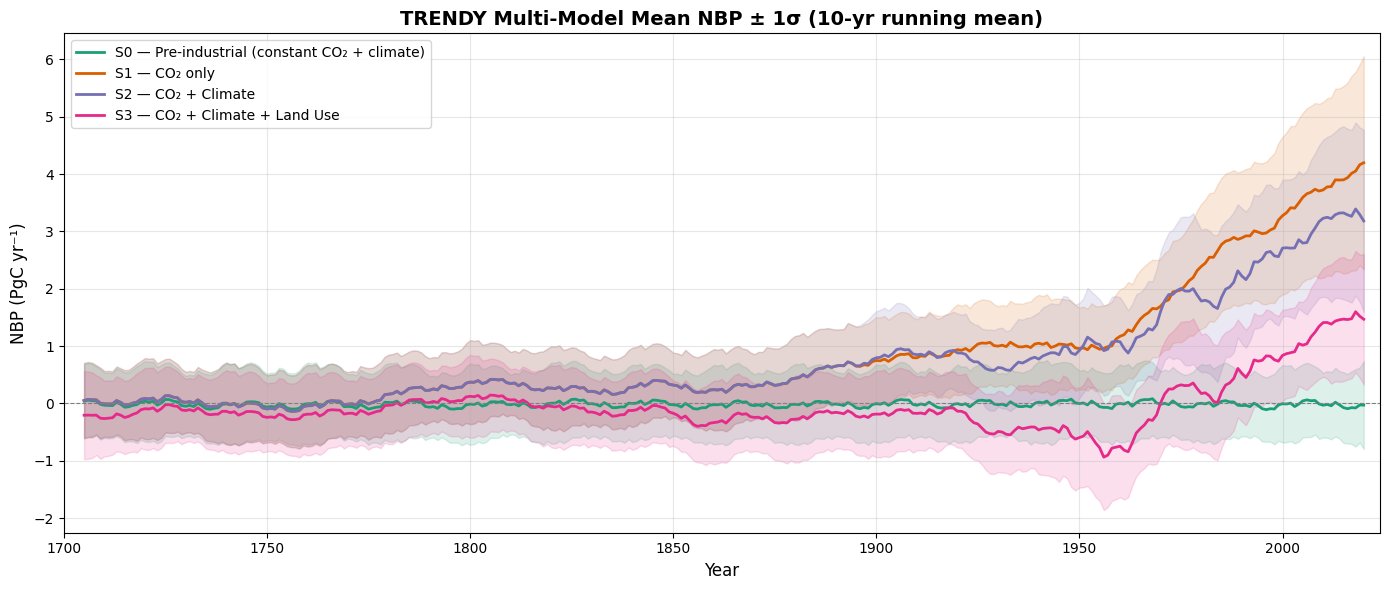

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

exp_labels = {
    'S0': 'S0 — Pre-industrial (constant CO₂ + climate)',
    'S1': 'S1 — CO₂ only',
    'S2': 'S2 — CO₂ + Climate',
    'S3': 'S3 — CO₂ + Climate + Land Use',
}

for exp in experiments:
    sub = df[df['experiment'] == exp]
    pivot = sub.pivot_table(index='year', columns='model', values='nbp_PgC_yr')
    
    # Require at least 3 models per year
    mask = pivot.count(axis=1) >= 3
    mmm = pivot.loc[mask].mean(axis=1)
    msd = pivot.loc[mask].std(axis=1)
    
    # Apply 10-year running mean
    mmm_smooth = mmm.rolling(10, center=True).mean()
    msd_smooth = msd.rolling(10, center=True).mean()
    
    color = exp_colors[exp]
    ax.plot(mmm_smooth.index, mmm_smooth.values, color=color, linewidth=2, label=exp_labels[exp])
    ax.fill_between(mmm_smooth.index, (mmm_smooth - msd_smooth).values, (mmm_smooth + msd_smooth).values, 
                    color=color, alpha=0.15)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('NBP (PgC yr⁻¹)', fontsize=12)
ax.set_title('TRENDY Multi-Model Mean NBP ± 1σ (10-yr running mean)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(1700, 2024)
plt.tight_layout()
plt.show()

## Recent Period Zoom (1960–2024)

Focus on the recent period where the experiment divergence is most visible.

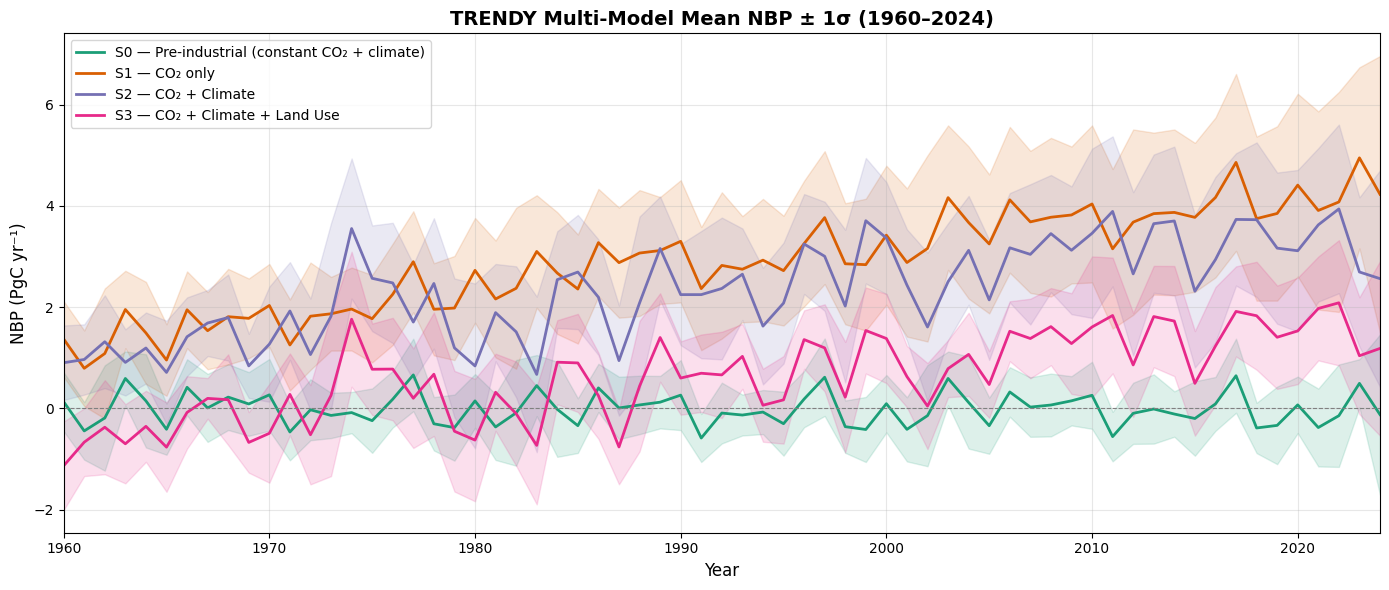

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

for exp in experiments:
    sub = df[(df['experiment'] == exp) & (df['year'] >= 1960)]
    pivot = sub.pivot_table(index='year', columns='model', values='nbp_PgC_yr')
    
    mask = pivot.count(axis=1) >= 3
    mmm = pivot.loc[mask].mean(axis=1)
    msd = pivot.loc[mask].std(axis=1)
    
    # Apply 10-year running mean
    mmm_smooth = mmm.rolling(10, center=True).mean()
    msd_smooth = msd.rolling(10, center=True).mean()
    
    color = exp_colors[exp]
    ax.plot(mmm_smooth.index, mmm_smooth.values, color=color, linewidth=2, label=exp_labels[exp])
    ax.fill_between(mmm_smooth.index, (mmm_smooth - msd_smooth).values, (mmm_smooth + msd_smooth).values, 
                    color=color, alpha=0.15)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('NBP (PgC yr⁻¹)', fontsize=12)
ax.set_title('TRENDY Multi-Model Mean NBP ± 1σ (1960–2024, 10-yr running mean)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')

ax.grid(True, alpha=0.3)plt.show()

ax.set_xlim(1960, 2024)plt.tight_layout()

## Land Use Effect: S3 − S2

The difference S3 − S2 isolates the impact of land-use change. Shading shows the full model spread (min–max), with the multi-model mean as a solid line.

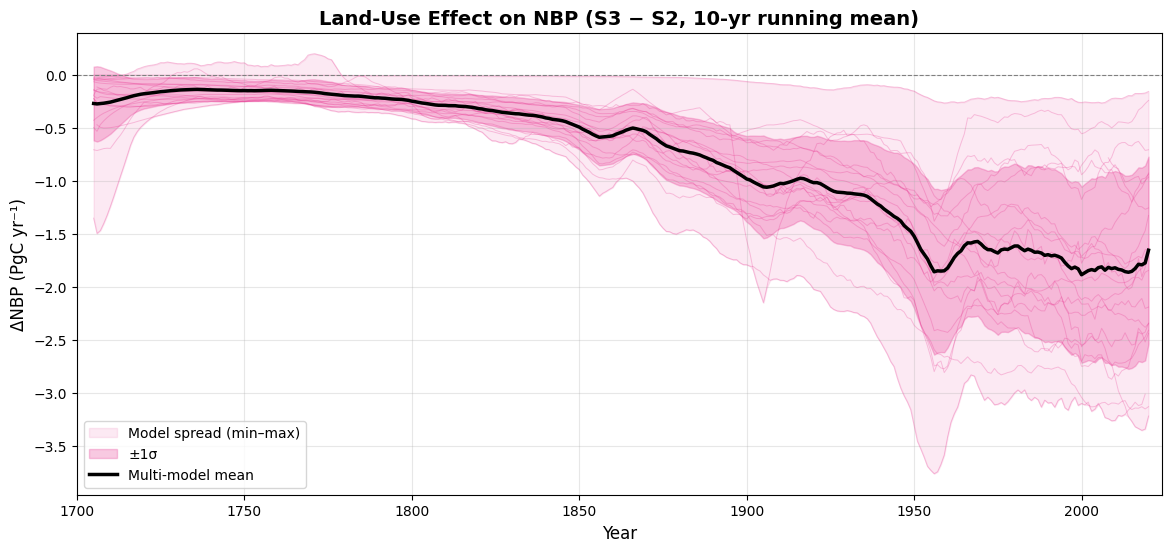

<Figure size 640x480 with 0 Axes>

In [10]:
# Compute S3 - S2 for each model
s3 = df[df['experiment'] == 'S3'].pivot_table(index='year', columns='model', values='nbp_PgC_yr')
s2 = df[df['experiment'] == 'S2'].pivot_table(index='year', columns='model', values='nbp_PgC_yr')

# Only use models present in both experiments
common_models = s3.columns.intersection(s2.columns)
diff = s3[common_models] - s2[common_models]

# Require at least 3 models per year
mask = diff.count(axis=1) >= 3
diff = diff.loc[mask]

fig, ax = plt.subplots(figsize=(14, 6))

# Apply 10-year running mean to each model
diff_smooth = diff.rolling(10, center=True).mean()

# Individual models as thin lines
for model in common_models:
    ax.plot(diff_smooth.index, diff_smooth[model], alpha=0.25, linewidth=0.7, color='#e7298a')

# Min-max shading
ax.fill_between(diff_smooth.index, diff_smooth.min(axis=1), diff_smooth.max(axis=1),
                color='#e7298a', alpha=0.1, label='Model spread (min–max)')

# ±1σ shading
mmm = diff_smooth.mean(axis=1)
msd = diff_smooth.std(axis=1)
ax.fill_between(diff_smooth.index, (mmm - msd), (mmm + msd),
                color='#e7298a', alpha=0.25, label='±1σ')

# Multi-model mean
ax.plot(diff_smooth.index, mmm, color='black', linewidth=2.5, label='Multi-model mean', zorder=10)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('ΔNBP (PgC yr⁻¹)', fontsize=12)
ax.set_title('Land-Use Effect on NBP (S3 − S2, 10-yr running mean)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, alpha=0.3)

ax.set_xlim(1700, 2024)
plt.show()
plt.tight_layout()